# Time series forecasting 

## Importación de librerías y paquetes y definición de constantes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
# Modelado
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import set_random_seed
# To save models
import json
import pickle
# from tqdm import tqdm
import warnings


In [2]:
seed = set_random_seed(24)
data_dir_train = os.path.abspath(os.path.join(os.getcwd(), '..','..', 'dogs_vs_cats', 'train'))
data_dir_test = os.path.abspath(os.path.join(os.getcwd(), '..','..', 'dogs_vs_cats', 'test'))
print(data_dir_train)

c:\Users\Simón\dogs_vs_cats\train


In [2]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Generación del conjunto de train y test

### Train

In [3]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   validation_split=0.2)
# Cargar imágenes desde directorio
train_generator = train_datagen.flow_from_directory(
    data_dir_train,
    target_size=(224, 224),      # redimensiona las imágenes
    batch_size=32,
    class_mode='categorical',     # 'binary', 'categorical', 'sparse', 'input', o None
    subset='training',
    seed = seed
)

Found 16000 images belonging to 2 classes.


In [4]:
val_generator = train_datagen.flow_from_directory(
    data_dir_train,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=42
)


Found 4000 images belonging to 2 classes.


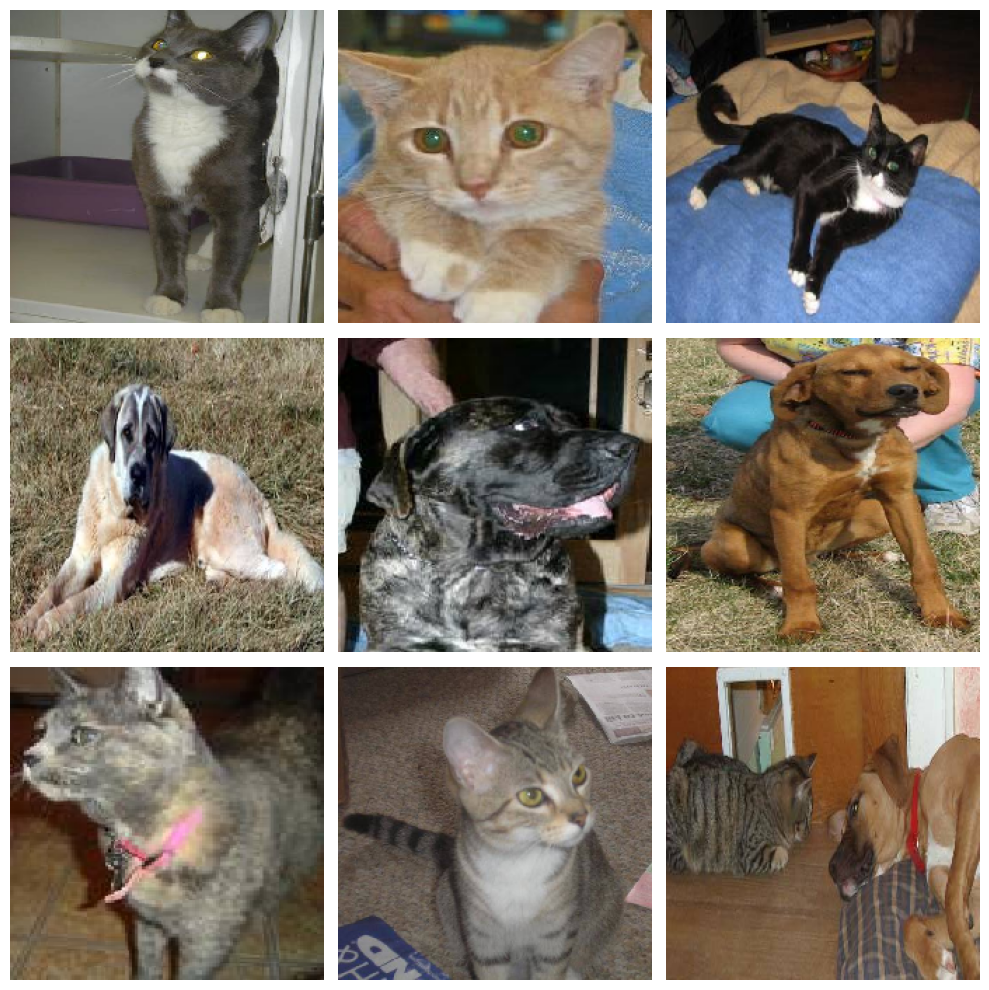

In [5]:
# Obtener un lote del generador
images, labels = next(train_generator)  # siguiente lote

# Mostrar las primeras 9 imágenes
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

### Test

In [6]:
test_datagen = ImageDataGenerator(rescale=1./255)

# Cargar imágenes desde el directorio de validación/test
test_generator = test_datagen.flow_from_directory(
    data_dir_test,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',   # Usa el mismo class_mode que en entrenamiento
    shuffle=False,              # ¡Importante para evaluar o predecir!
    seed = seed
)

Found 5000 images belonging to 2 classes.


## Generación y ajuste del modelo

#### Definición de arquitectura `VGG16`

In [15]:
model = Sequential()
model.add(Conv2D(input_shape = (224,224,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 64,kernel_size = (3,3),padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Flatten())
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 2, activation = "softmax"))

In [ ]:
model.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics = ["accuracy"])
model

In [ ]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)